# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [2]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [3]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

from pathlib import Path

DATA_DIR = Path('../data/raw/archive')
DATA_PATH = DATA_DIR / 'flights.csv'
AIRLINES_PATH = DATA_DIR / 'airlines.csv'
AIRPORTS_PATH = DATA_DIR / 'airports.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
airlines_df = pd.read_csv(AIRLINES_PATH)
airports_df = pd.read_csv(AIRPORTS_PATH)

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Verify the data loaded correctly by displaying shape and a sample
print(f"Flights dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Airlines lookup shape: {airlines_df.shape[0]} rows x {airlines_df.shape[1]} columns")
print(f"Airports lookup shape: {airports_df.shape[0]} rows x {airports_df.shape[1]} columns")

df.sample(5, random_state=42)

Flights dataset shape: 5819079 rows x 31 columns
Airlines lookup shape: 14 rows x 2 columns
Airports lookup shape: 322 rows x 7 columns


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Document data source details
data_source_report = {
    "source": "Kaggle - 2015 Flight Delays and Cancellations dataset",
    "acquisition_method": "CSV download placed in data/raw/archive",
    "issues_encountered": [
        "The main flights file is large, so loading may take large amount of time and memory.",
        "Several operational columns are expected to contain missing values because cancelled flights do not have completed departure or arrival records.",
        "Secondary lookup tables for airlines and airports are stored separately and may require joins in later phases."
    ]
}
print(data_source_report)

{'source': 'Kaggle - 2015 Flight Delays and Cancellations dataset', 'acquisition_method': 'CSV download placed in data/raw/archive', 'issues_encountered': ['The main flights file is large, so loading may take large amount of time and memory.', 'Several operational columns are expected to contain missing values because cancelled flights do not have completed departure or arrival records.', 'Secondary lookup tables for airlines and airports are stored separately and may require joins in later phases.']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [6]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.

print(f"Dataset volume: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.info()

column_roles = []
for column in df.columns:
    if column in ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER']:
        role = 'identifier_or_schedule_feature'
    elif 'AIRPORT' in column:
        role = 'location_feature'
    elif 'TIME' in column or 'DELAY' in column or column in ['DISTANCE', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME', 'DIVERTED', 'CANCELLED']:
        role = 'operational_feature_or_outcome'
    elif column == 'CANCELLATION_REASON':
        role = 'cancellation_outcome_detail'
    else:
        role = 'feature'
    column_roles.append({
        'column': column,
        'dtype': str(df[column].dtype),
        'non_null_count': int(df[column].notna().sum()),
        'role': role
    })

schema_report = pd.DataFrame(column_roles)
schema_report

Dataset volume: 5819079 rows x 31 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        fl

,column,dtype,non_null_count,role
0,YEAR,int64,5819079,identifier_or_schedule_feature
1,MONTH,int64,5819079,identifier_or_schedule_feature
2,DAY,int64,5819079,identifier_or_schedule_feature
3,DAY_OF_WEEK,int64,5819079,identifier_or_schedule_feature
4,AIRLINE,object,5819079,identifier_or_schedule_feature
5,FLIGHT_NUMBER,int64,5819079,identifier_or_schedule_feature
6,TAIL_NUMBER,object,5804358,identifier_or_schedule_feature
7,ORIGIN_AIRPORT,object,5819079,location_feature
8,DESTINATION_AIRPORT,object,5819079,location_feature
9,SCHEDULED_DEPARTURE,int64,5819079,feature


In [7]:
# Generate descriptive statistics for numerical columns
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [8]:
# Generate descriptive statistics for categorical columns
categorical_summary = df.describe(include='object')
display(categorical_summary)

# Or inspect value counts for specific categorical columns:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))

,AIRLINE,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,CANCELLATION_REASON
count,5819079,5804358,5819079,5819079,89884
unique,14,4897,628,629,4
top,WN,N480HA,ATL,ATL,B
freq,1261855,3768,346836,346904,48851



--- AIRLINE ---
AIRLINE
WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
Name: count, dtype: int64

--- TAIL_NUMBER ---
TAIL_NUMBER
NaN       14721
N480HA     3768
N488HA     3723
N484HA     3723
N493HA     3585
N478HA     3577
N483HA     3528
N486HA     3513
N491HA     3494
N489HA     3477
Name: count, dtype: int64

--- ORIGIN_AIRPORT ---
ORIGIN_AIRPORT
ATL    346836
ORD    285884
DFW    239551
DEN    196055
LAX    194673
SFO    148008
PHX    146815
IAH    146622
LAS    133181
MSP    112117
Name: count, dtype: int64

--- DESTINATION_AIRPORT ---
DESTINATION_AIRPORT
ATL    346904
ORD    285906
DFW    239582
DEN    196010
LAX    194696
SFO    147966
PHX    146812
IAH    146683
LAS    133198
MSP    112128
Name: count, dtype: int64

--- CANCELLATION_REASON ---
CANCELLATION_REASON
NaN    5729195
B        48851
A        25262
C        15749
D           22
Name: count, dtype: int64


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

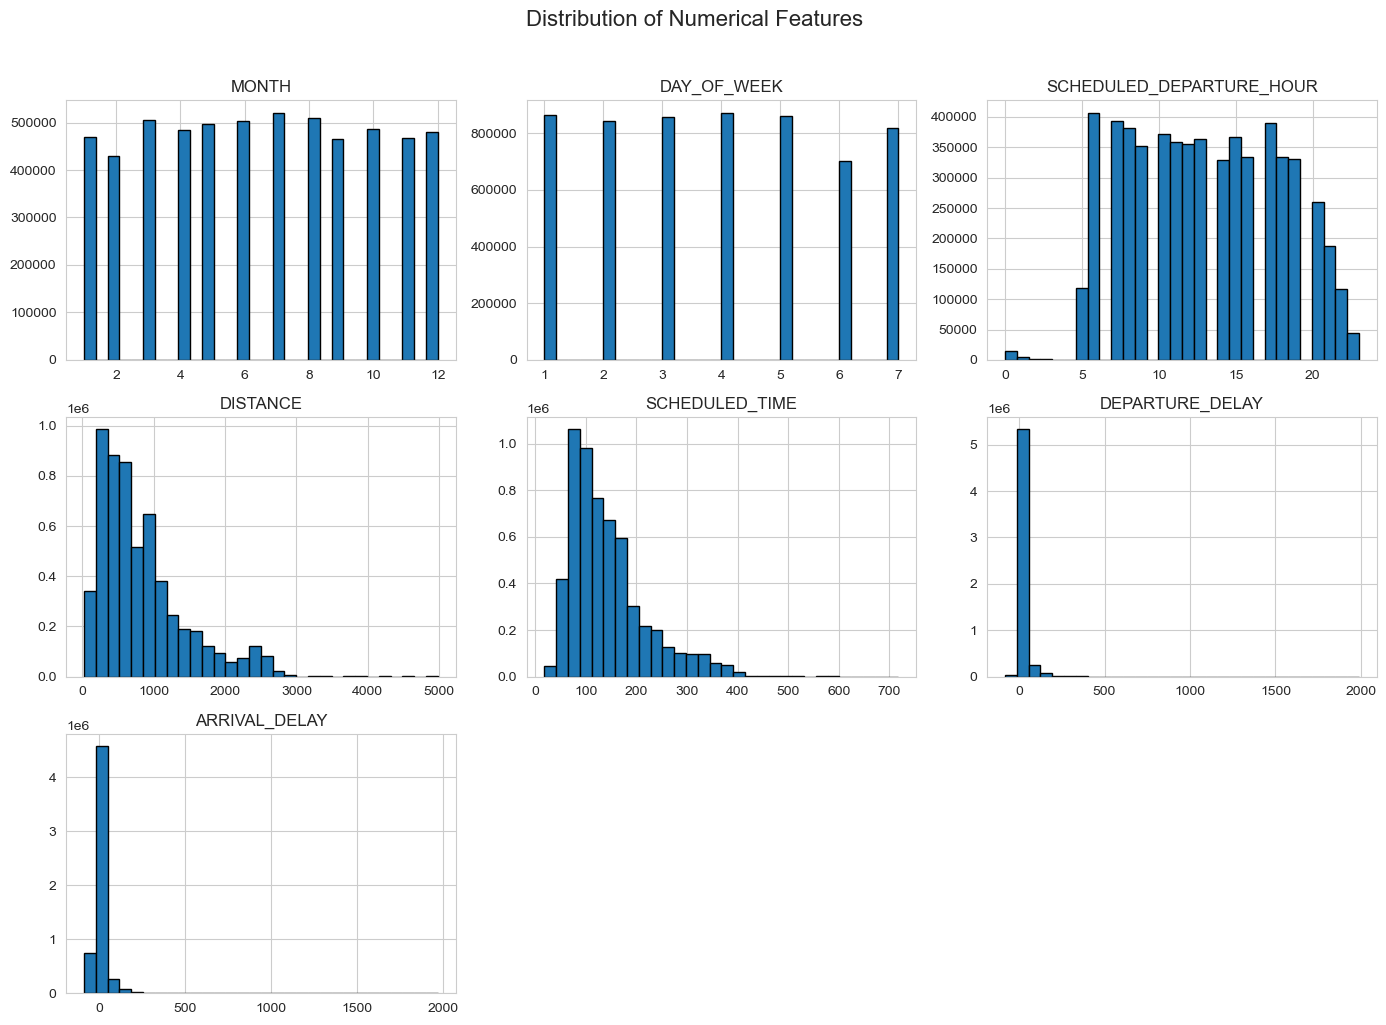

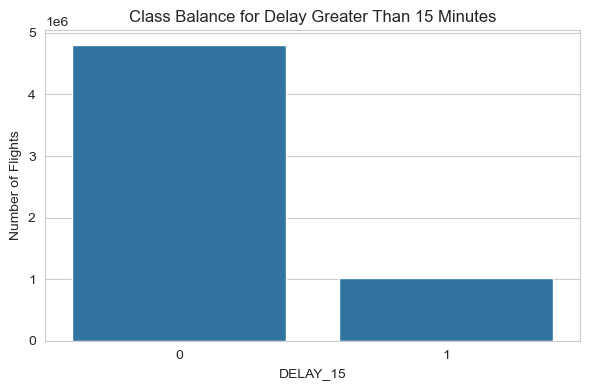

In [9]:
# TODO: Perform univariate analysis — explore distributions of individual features.
# Example: Histograms for numerical columns

df['DELAY_15'] = (df['DEPARTURE_DELAY'] > 15).astype(int)
df['SCHEDULED_DEPARTURE_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).clip(lower=0, upper=23)

selected_numerical_cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE_HOUR',
    'DISTANCE',
    'SCHEDULED_TIME',
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY'
]
selected_numerical_cols = [col for col in selected_numerical_cols if col in df.columns]

df[selected_numerical_cols].hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DELAY_15')
plt.title('Class Balance for Delay Greater Than 15 Minutes')
plt.xlabel('DELAY_15')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

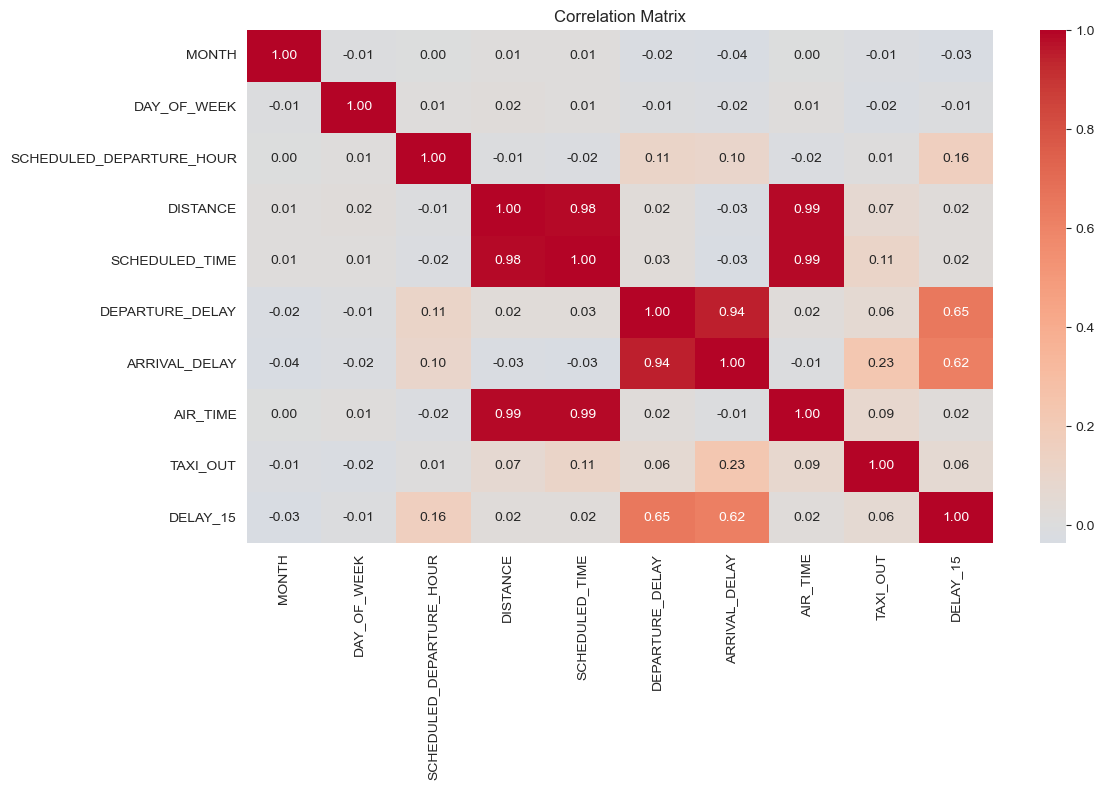

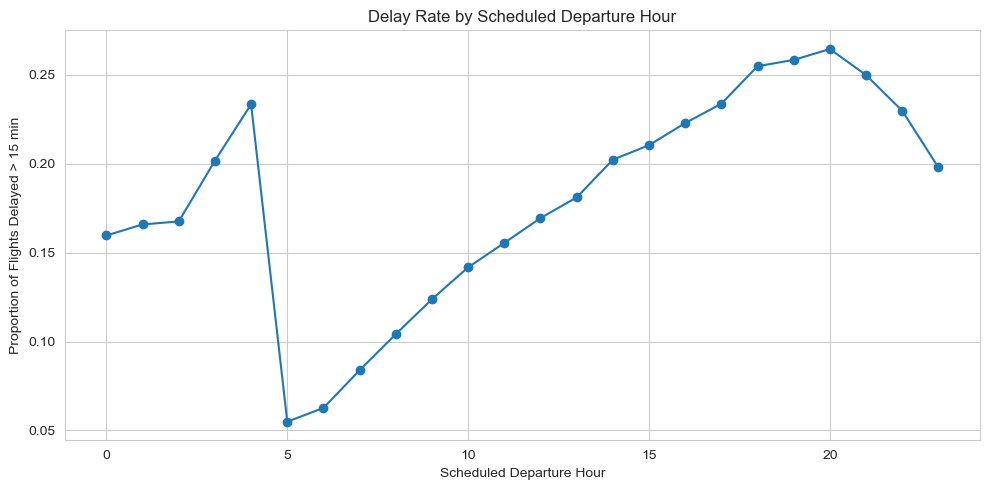

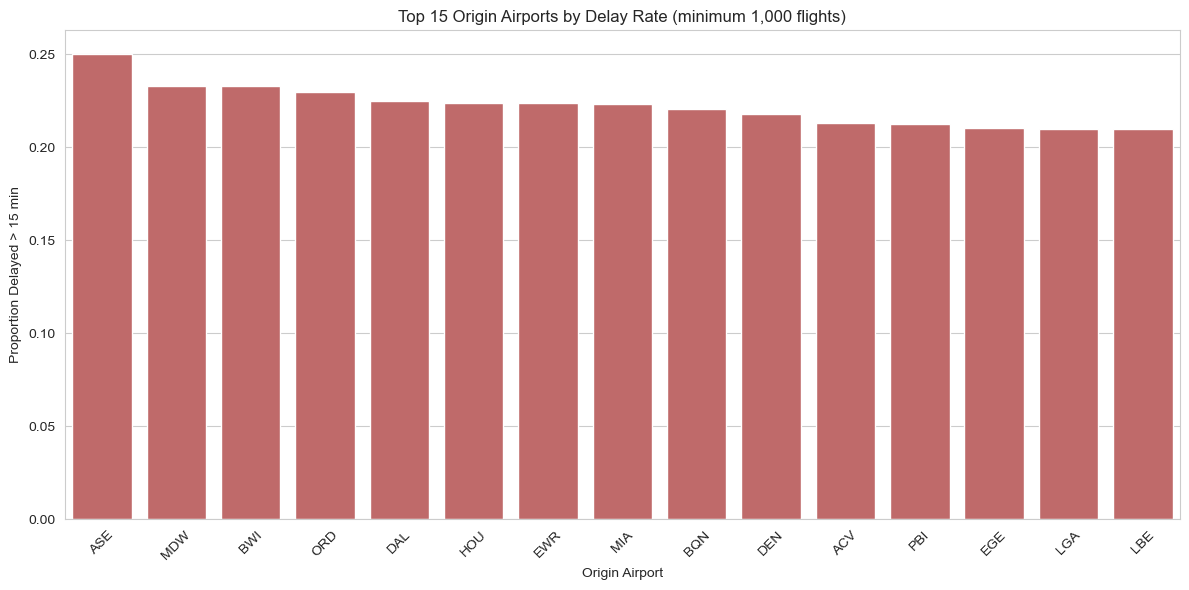

,,mean,count
ORIGIN_AIRPORT,DESTINATION_AIRPORT,,
SJU,EWR,0.349791,1195
DFW,OGG,0.349206,504
IAH,LAX,0.348601,4432
ORD,SMF,0.348315,534
DFW,HNL,0.340029,697
ORD,ASE,0.335484,620
IAH,SFO,0.329747,3439
MDW,ORF,0.328996,538
LGA,MCI,0.328212,716


In [10]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

analysis_cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE_HOUR',
    'DISTANCE',
    'SCHEDULED_TIME',
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'AIR_TIME',
    'TAXI_OUT',
    'DELAY_15'
]
analysis_cols = [col for col in analysis_cols if col in df.columns]

plt.figure(figsize=(12, 8))
correlation_matrix = df[analysis_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

hourly_delay_rate = (
    df.groupby('SCHEDULED_DEPARTURE_HOUR')['DELAY_15']
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 5))
hourly_delay_rate.plot(marker='o')
plt.title('Delay Rate by Scheduled Departure Hour')
plt.xlabel('Scheduled Departure Hour')
plt.ylabel('Proportion of Flights Delayed > 15 min')
plt.tight_layout()
plt.show()

top_origin_delay = (
    df.groupby('ORIGIN_AIRPORT')['DELAY_15']
      .agg(['mean', 'count'])
      .query('count >= 1000')
      .sort_values('mean', ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_origin_delay.index, y=top_origin_delay['mean'], color='indianred')
plt.title('Top 15 Origin Airports by Delay Rate (minimum 1,000 flights)')
plt.xlabel('Origin Airport')
plt.ylabel('Proportion Delayed > 15 min')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

route_summary = (
    df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['DELAY_15']
      .agg(['mean', 'count'])
      .query('count >= 500')
      .sort_values('mean', ascending=False)
      .head(10)
)
route_summary

In [15]:
# TODO: Document any initial insights or hypotheses from your exploration.

delay_rate = df['DELAY_15'].mean()
peak_hour = hourly_delay_rate.idxmax()
lowest_hour = hourly_delay_rate.idxmin()
top_origin = top_origin_delay.index[0]
top_route = route_summary.index[0] if len(route_summary) > 0 else ('N/A', 'N/A')

initial_insights = [
    f"Around {delay_rate:.2%} of flights in the dataset were delayed by more than 15 minutes.",
    f"The highest delay rate appeared around hour {peak_hour}, while the lowest was around hour {lowest_hour}.",
    f"The origin airport with the highest average departure delay in the initial exploration was {top_origin}.",
    f"The route with the highest average delay in the explored results was {top_route}.",
    "These early results suggest that things like time of day, airport, and route are linked to delay patterns."
]

for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

1. Around 17.50% of flights in the dataset were delayed by more than 15 minutes.
2. The highest delay rate appeared around hour 20, while the lowest was around hour 5.
3. The origin airport with the highest average departure delay in the initial exploration was ASE.
4. The route with the highest average delay in the explored results was ('SJU', 'EWR').
5. These early results suggest that things like time of day, airport, and route are linked to delay patterns.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [12]:
# TODO: Check for missing values.

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=== Missing Values Report ===")
print(missing_report)
print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
                     Missing Count  Missing %
CANCELLATION_REASON        5729195  98.455357
SECURITY_DELAY             4755640  81.724960
AIR_SYSTEM_DELAY           4755640  81.724960
LATE_AIRCRAFT_DELAY        4755640  81.724960
WEATHER_DELAY              4755640  81.724960
AIRLINE_DELAY              4755640  81.724960
ARRIVAL_DELAY               105071   1.805629
ELAPSED_TIME                105071   1.805629
AIR_TIME                    105071   1.805629
TAXI_IN                      92513   1.589822
WHEELS_ON                    92513   1.589822
ARRIVAL_TIME                 92513   1.589822
TAXI_OUT                     89047   1.530259
WHEELS_OFF                   89047   1.530259
DEPARTURE_DELAY              86153   1.480526
DEPARTURE_TIME               86153   1.480526
TAIL_NUMBER                  14721   0.252978
SCHEDULED_TIME                   6   0.000103

Total columns with missing values: 18


In [13]:
# TODO: Check for duplicate records.

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 0


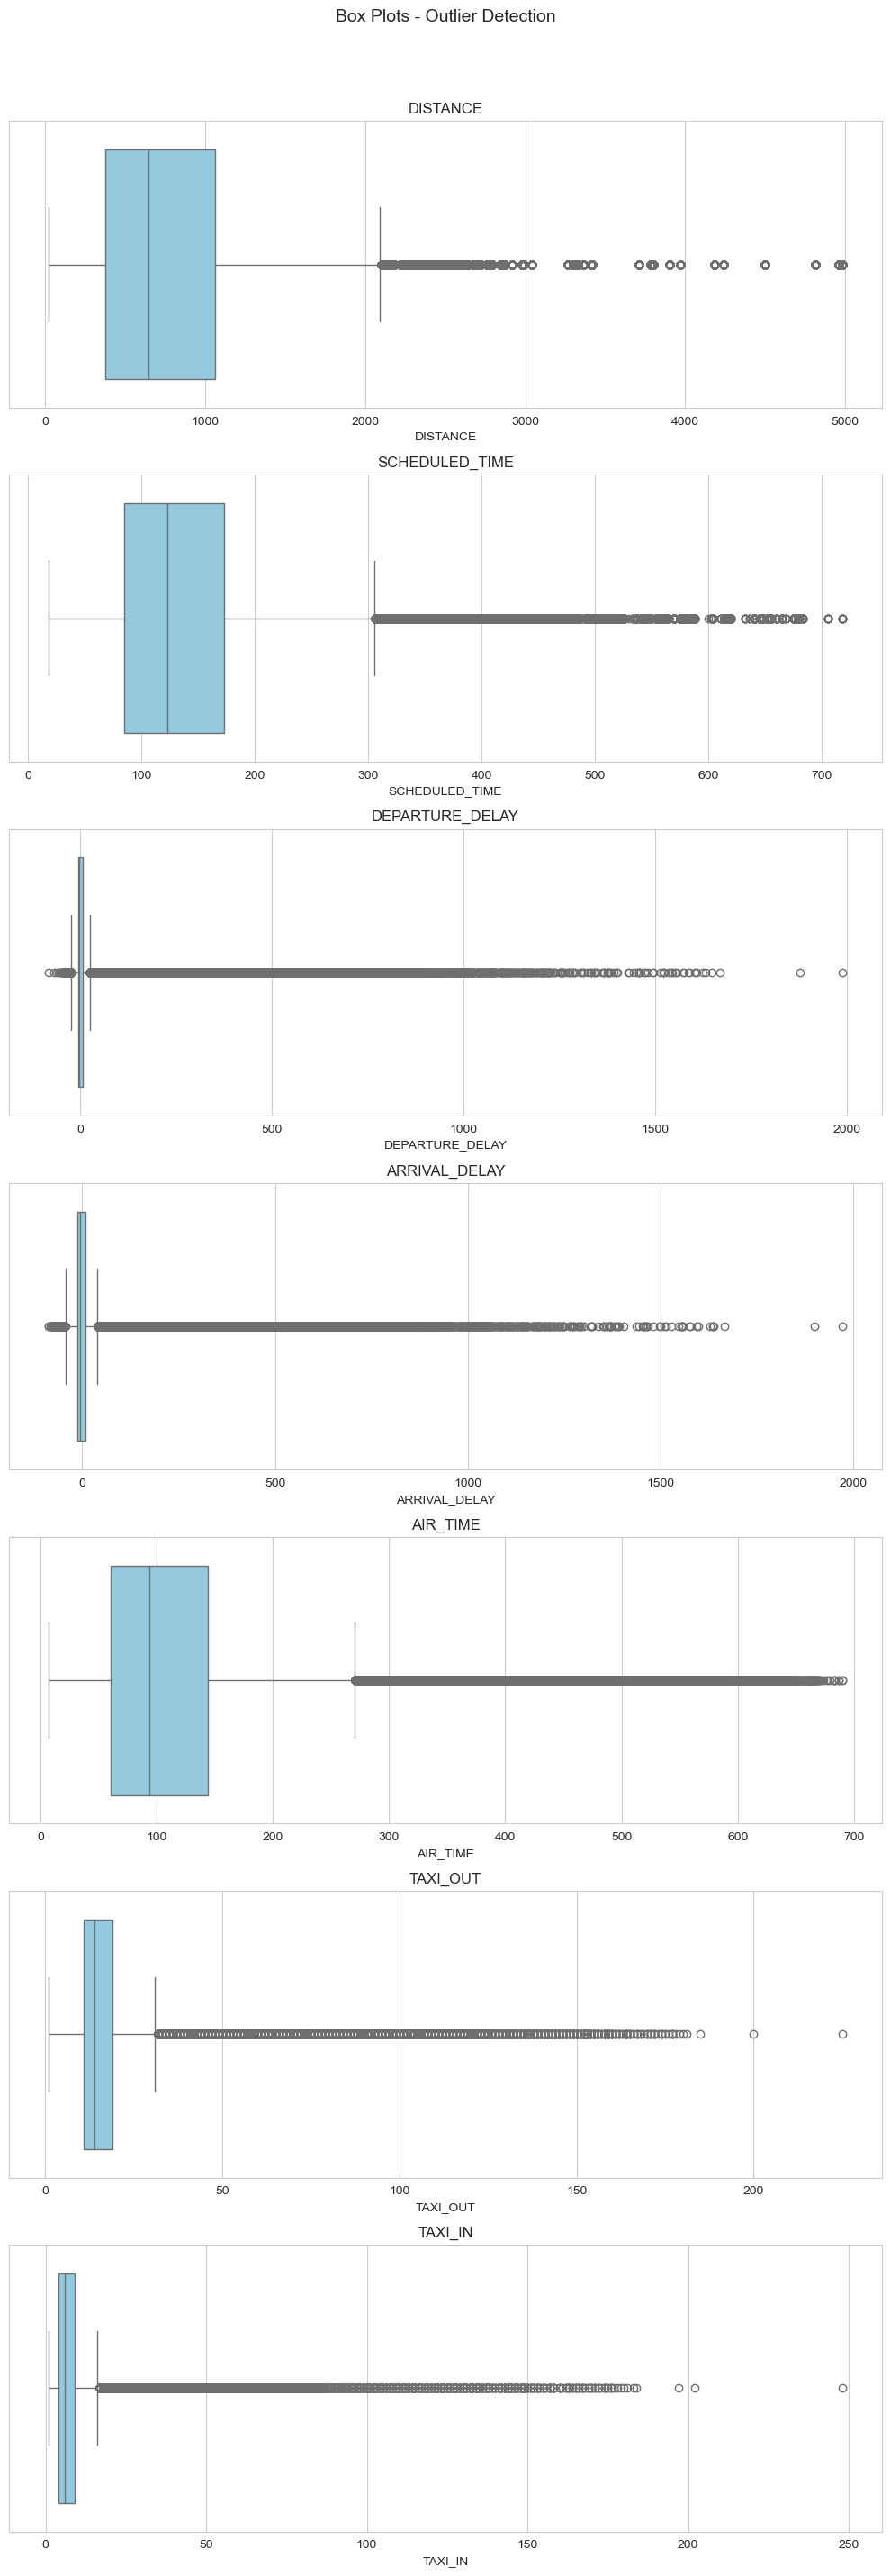

=== Outlier Summary (IQR method) ===
                 lower_bound  upper_bound  outlier_count
DISTANCE              -660.5       2095.5       349511.0
SCHEDULED_TIME         -47.0        305.0       299011.0
DEPARTURE_DELAY        -23.0         25.0       736242.0
ARRIVAL_DELAY          -44.5         39.5       512002.0
AIR_TIME               -66.0        270.0       296342.0
TAXI_OUT                -1.0         31.0       282602.0
TAXI_IN                 -3.5         16.5       282538.0

=== Inconsistency Checks ===
{'negative_scheduled_time': 0, 'negative_distance': 0, 'negative_taxi_out': 0, 'negative_taxi_in': 0, 'departure_time_over_2359': 0, 'arrival_time_over_2359': 2, 'cancelled_not_binary': 0, 'diverted_not_binary': 0}


In [14]:
# TODO: Detect outliers using box plots or statistical methods.

outlier_columns = ['DISTANCE', 'SCHEDULED_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']
outlier_columns = [col for col in outlier_columns if col in df.columns]

if outlier_columns:
    fig, axes = plt.subplots(nrows=len(outlier_columns), ncols=1, figsize=(10, 4 * len(outlier_columns)))
    if len(outlier_columns) == 1:
        axes = [axes]
    for ax, col in zip(axes, outlier_columns):
        sns.boxplot(x=df[col].dropna(), ax=ax, color='skyblue')
        ax.set_title(col)
    plt.suptitle('Box Plots - Outlier Detection', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

outlier_summary = {}
for col in outlier_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
    outlier_summary[col] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': int(outlier_count)
    }

print("=== Outlier Summary (IQR method) ===")
print(pd.DataFrame(outlier_summary).T)

inconsistencies = {
    'negative_scheduled_time': int((df['SCHEDULED_TIME'] < 0).sum()) if 'SCHEDULED_TIME' in df.columns else 0,
    'negative_distance': int((df['DISTANCE'] < 0).sum()) if 'DISTANCE' in df.columns else 0,
    'negative_taxi_out': int((df['TAXI_OUT'] < 0).sum()) if 'TAXI_OUT' in df.columns else 0,
    'negative_taxi_in': int((df['TAXI_IN'] < 0).sum()) if 'TAXI_IN' in df.columns else 0,
    'departure_time_over_2359': int((df['SCHEDULED_DEPARTURE'] > 2359).sum()) if 'SCHEDULED_DEPARTURE' in df.columns else 0,
    'arrival_time_over_2359': int((df['SCHEDULED_ARRIVAL'] > 2359).sum()) if 'SCHEDULED_ARRIVAL' in df.columns else 0,
    'cancelled_not_binary': int((~df['CANCELLED'].isin([0, 1])).sum()) if 'CANCELLED' in df.columns else 0,
    'diverted_not_binary': int((~df['DIVERTED'].isin([0, 1])).sum()) if 'DIVERTED' in df.columns else 0
}

print("\n=== Inconsistency Checks ===")
print(inconsistencies)